In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
data = pd.read_csv('cyber_threat_dataset.csv')

In [4]:
data.head()

,text,label
0,Launch the phishing attack,1
1,Steal the credentials and gain access,1
2,Use VPN to protect online privacy,0
3,Initiate the DDoS attack,1
4,Let's encrypt the files for security,0


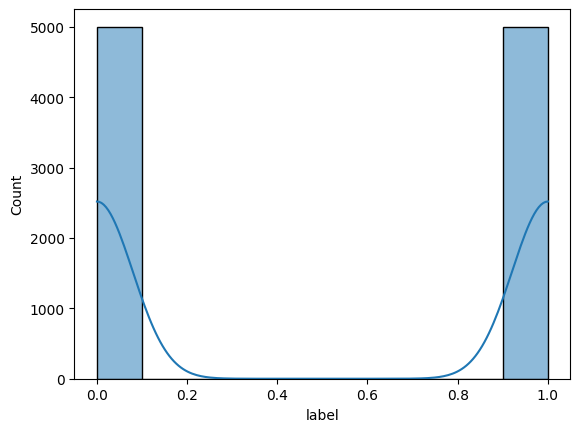

In [5]:
sns.histplot(data['label'],bins=10, kde=True)
plt.show()

In [42]:
d = data['text']
d.head()

0               Launch the phishing attack
1    Steal the credentials and gain access
2        Use VPN to protect online privacy
3                 Initiate the DDoS attack
4     Let's encrypt the files for security
Name: text, dtype: object

In [54]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(max_features=80)
vectors = vectorizer.fit_transform(d)
vectors

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 52070 stored elements and shape (10000, 80)>

In [55]:
vectors1 = vectors.toarray()
vectors1

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.41167421, 0.        , 0.36296769, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.40142018, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

In [56]:
vectors1.shape

(10000, 80)

In [57]:
vectors1 = pd.DataFrame(vectors1)
vectors1['label'] = data['label']
vectors1.head()

,0,1,2,3,4,5,6,7,8,9,...,71,72,73,74,75,76,77,78,79,label
0,0.000000,0.0,0.000000,0.0,0.519488,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.00000,0.00000,0.0,0.0,0.0,0.0,1
1,0.411674,0.0,0.362968,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.00000,0.00000,0.0,0.0,0.0,0.0,1
2,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.41925,0.41925,0.0,0.0,0.0,0.0,0
3,0.000000,0.0,0.000000,0.0,0.492244,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.00000,0.00000,0.0,0.0,0.0,0.0,1
4,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.00000,0.00000,0.0,0.0,0.0,0.0,0


In [58]:
x = vectors1.drop('label', axis=1)
y = vectors1['label']

In [59]:
x

,0,1,2,3,4,5,6,7,8,9,...,70,71,72,73,74,75,76,77,78,79
0,0.000000,0.0,0.000000,0.0,0.519488,0.0,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.0,0.00000,0.00000,0.0,0.0,0.0,0.0
1,0.411674,0.0,0.362968,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.0,0.00000,0.00000,0.0,0.0,0.0,0.0
2,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.0,0.41925,0.41925,0.0,0.0,0.0,0.0
3,0.000000,0.0,0.000000,0.0,0.492244,0.0,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.0,0.00000,0.00000,0.0,0.0,0.0,0.0
4,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.0,0.00000,0.00000,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0.000000,0.0,0.000000,0.0,0.519488,0.0,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.0,0.00000,0.00000,0.0,0.0,0.0,0.0
9996,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.432139,0.0,...,0.000000,0.0,0.0,0.0,0.00000,0.00000,0.0,0.0,0.0,0.0
9997,0.000000,0.0,0.000000,0.0,0.519488,0.0,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.0,0.00000,0.00000,0.0,0.0,0.0,0.0
9998,0.401420,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,...,0.488815,0.0,0.0,0.0,0.00000,0.00000,0.0,0.0,0.0,0.0


In [60]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

In [61]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
model.fit(x_train, y_train)

RandomForestClassifier()

In [62]:
model.score(x_test, y_test)*100, model.score(x_train, y_train)*100

(100.0, 100.0)

In [63]:
from sklearn.metrics import classification_report,confusion_matrix
y_pred = model.predict(x_test)
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)


              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1260
           1       1.00      1.00      1.00      1240

    accuracy                           1.00      2500
   macro avg       1.00      1.00      1.00      2500
weighted avg       1.00      1.00      1.00      2500

Confusion Matrix:
[[1260    0]
 [   0 1240]]


In [65]:
import pickle
pickle.dump(model,open('cctv_audio_model.pkl','wb'))
pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))
print("Model trained and saved!")


Model trained and saved!
